# Protein Structure Classification Project

Google Colab notebooks for a protein structure classification includes:
- Data loading and drive mounting
- Data merging and cleaning (removing duplicates, filtering, and dropping unnecessary columns)
- Exploratory Data Analysis (EDA)
- Feature encoding and train-test split
- Model building using Random Forest and K-Nearest Neighbors (KNN)
  
**Notes:**
- Only proteins (rows with `macromoleculeType` equal to "Protein" or "Protein#RNA") are used.
- The data is filtered to keep only entries measured with "X-RAY DIFFRACTION".
- Only the three most frequent classes (e.g. HYDROLASE, TRANSFERASE, OXIDOREDUCTASE) are retained.
- The classification column is encoded via a dictionary mapping.
- Some hyperparameter tuning and alternative approaches are provided as commented code (Computationally heavy code)


In [ ]:
# %% [code]
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Set visualization style
sns.set(style="whitegrid")


# Mounting Google Drive and Data Loading


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

char_path='/content/drive/Othercomputers/My Laptop/Data Science/Projects Related to Data Science/Machine Learning Projects/Protine Structure Classification/pdb_data_no_dups.csv'

seq_path = '/content/drive/Othercomputers/My Laptop/Data Science/Projects Related to Data Science/Machine Learning Projects/Protine Structure Classification/pdb_data_seq.csv'

# Load the datasets
df_char = pd.read_csv(char_path)
df_seq = pd.read_csv(seq_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Merging and Cleaning

In this section, we:
- Merge the two datasets on the `structureId` column.
- Rename and drop duplicate columns.
- Filter to include only rows where the experimental technique is "X-RAY DIFFRACTION" and the macromolecule is a protein.
- Drop unnecessary columns (such as experimental metadata and the original sequence column).
- Filter the classification to only the three most frequent classes.
- Encode the target classes using a dictionary.
- Drop any remaining missing values.


In [ ]:
# %% [code]
import warnings
warnings.filterwarnings("ignore")

# Merge the datasets on 'structureId'
df = df_char.merge(df_seq, how='inner', on='structureId')

# Rename columns to resolve duplication
df.rename({'macromoleculeType_x': 'macromoleculeType',
           'residueCount_y': 'residueCount'}, axis=1, inplace=True)
df.drop(['macromoleculeType_y', 'residueCount_x'], axis=1, inplace=True)

# (Optional) Preview the merged data
print("Data preview:")
display(df.head())

# Filter for entries with experimental technique 'X-RAY DIFFRACTION'
df = df[df['experimentalTechnique'] == 'X-RAY DIFFRACTION']

# Filter for proteins (allowing 'Protein' and 'Protein#RNA')
df = df[df['macromoleculeType'].isin(['Protein', 'Protein#RNA'])]

# Drop columns that are not needed for analysis and modeling
cols_to_drop = ['crystallizationMethod',
                'pdbxDetails',
                'publicationYear',
                'phValue',
                'crystallizationTempK',
                'experimentalTechnique',
                'macromoleculeType',
                'chainId',
                'sequence']

df.drop(columns=[col for col in cols_to_drop if col in df.columns],
        inplace=True)


# Set 'structureId' as the index and remove it from columns
df = df.set_index('structureId', drop=True)

# Filter to keep only the top three classes by frequency
class_counts = df['classification'].value_counts()

top_classes = class_counts.nlargest(3).index
df = df[df['classification'].isin(top_classes)]

# Encode the three classes using a dictionary mapping
class_dict = {'HYDROLASE': 1, 'TRANSFERASE': 2, 'OXIDOREDUCTASE': 3}
df['class'] = df['classification'].map(class_dict)

# Drop the original classification column as we now have a numeric target
df.drop('classification', axis=1, inplace=True)

# Remove any remaining missing values
df.dropna(inplace=True)

# Display dataset information after cleaning
print("Cleaned DataFrame Info:")
df.info()
print("DataFrame shape:", df.shape)

Data preview:


,structureId,classification,experimentalTechnique,macromoleculeType,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear,chainId,sequence,residueCount
0,100D,DNA-RNA HYBRID,X-RAY DIFFRACTION,DNA/RNA Hybrid,1.90,6360.30,"VAPOR DIFFUSION, HANGING DROP",NaN,1.78,30.89,"pH 7.00, VAPOR DIFFUSION, HANGING DROP",7.0,1994.0,A,CCGGCGCCGG,20
1,100D,DNA-RNA HYBRID,X-RAY DIFFRACTION,DNA/RNA Hybrid,1.90,6360.30,"VAPOR DIFFUSION, HANGING DROP",NaN,1.78,30.89,"pH 7.00, VAPOR DIFFUSION, HANGING DROP",7.0,1994.0,B,CCGGCGCCGG,20
2,101D,DNA,X-RAY DIFFRACTION,DNA,2.25,7939.35,NaN,NaN,2.00,38.45,NaN,NaN,1995.0,A,CGCGAATTCGCG,24
3,101D,DNA,X-RAY DIFFRACTION,DNA,2.25,7939.35,NaN,NaN,2.00,38.45,NaN,NaN,1995.0,B,CGCGAATTCGCG,24
4,101M,OXYGEN TRANSPORT,X-RAY DIFFRACTION,Protein,2.07,18112.80,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.0,1999.0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,154


Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 111332 entries, 117E to 9NSE
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   resolution                111332 non-null  float64
 1   structureMolecularWeight  111332 non-null  float64
 2   densityMatthews           111332 non-null  float64
 3   densityPercentSol         111332 non-null  float64
 4   residueCount              111332 non-null  int64  
 5   class                     111332 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 5.9+ MB
DataFrame shape: (111332, 6)


# Exploratory Data Analysis (EDA)

Here we generate some basic statistical descriptions and visualizations:
- Summary statistics and correlation heatmap.
- A pairplot to visualize relationships between features.


In [ ]:
# %% [code]
# Basic statistics
print("Statistical Description:")
display(df.describe())

Statistical Description:


,resolution,structureMolecularWeight,densityMatthews,densityPercentSol,residueCount,class
count,111332.000000,1.113320e+05,111332.000000,111332.000000,111332.000000,111332.000000
mean,2.225258,1.834660e+05,2.686237,51.999582,1630.612591,1.909711
std,0.588825,2.460618e+05,0.646780,9.255372,2238.301655,0.823178
min,0.640000,2.379710e+03,0.970000,0.280000,20.000000,1.000000
25%,1.850000,5.494159e+04,2.270000,45.700000,484.000000,1.000000
50%,2.150000,1.058452e+05,2.510000,51.000000,932.000000,2.000000
75%,2.520000,2.140435e+05,2.910000,57.620000,1900.000000,3.000000
max,9.010000,4.918807e+06,13.890000,88.000000,57792.000000,3.000000


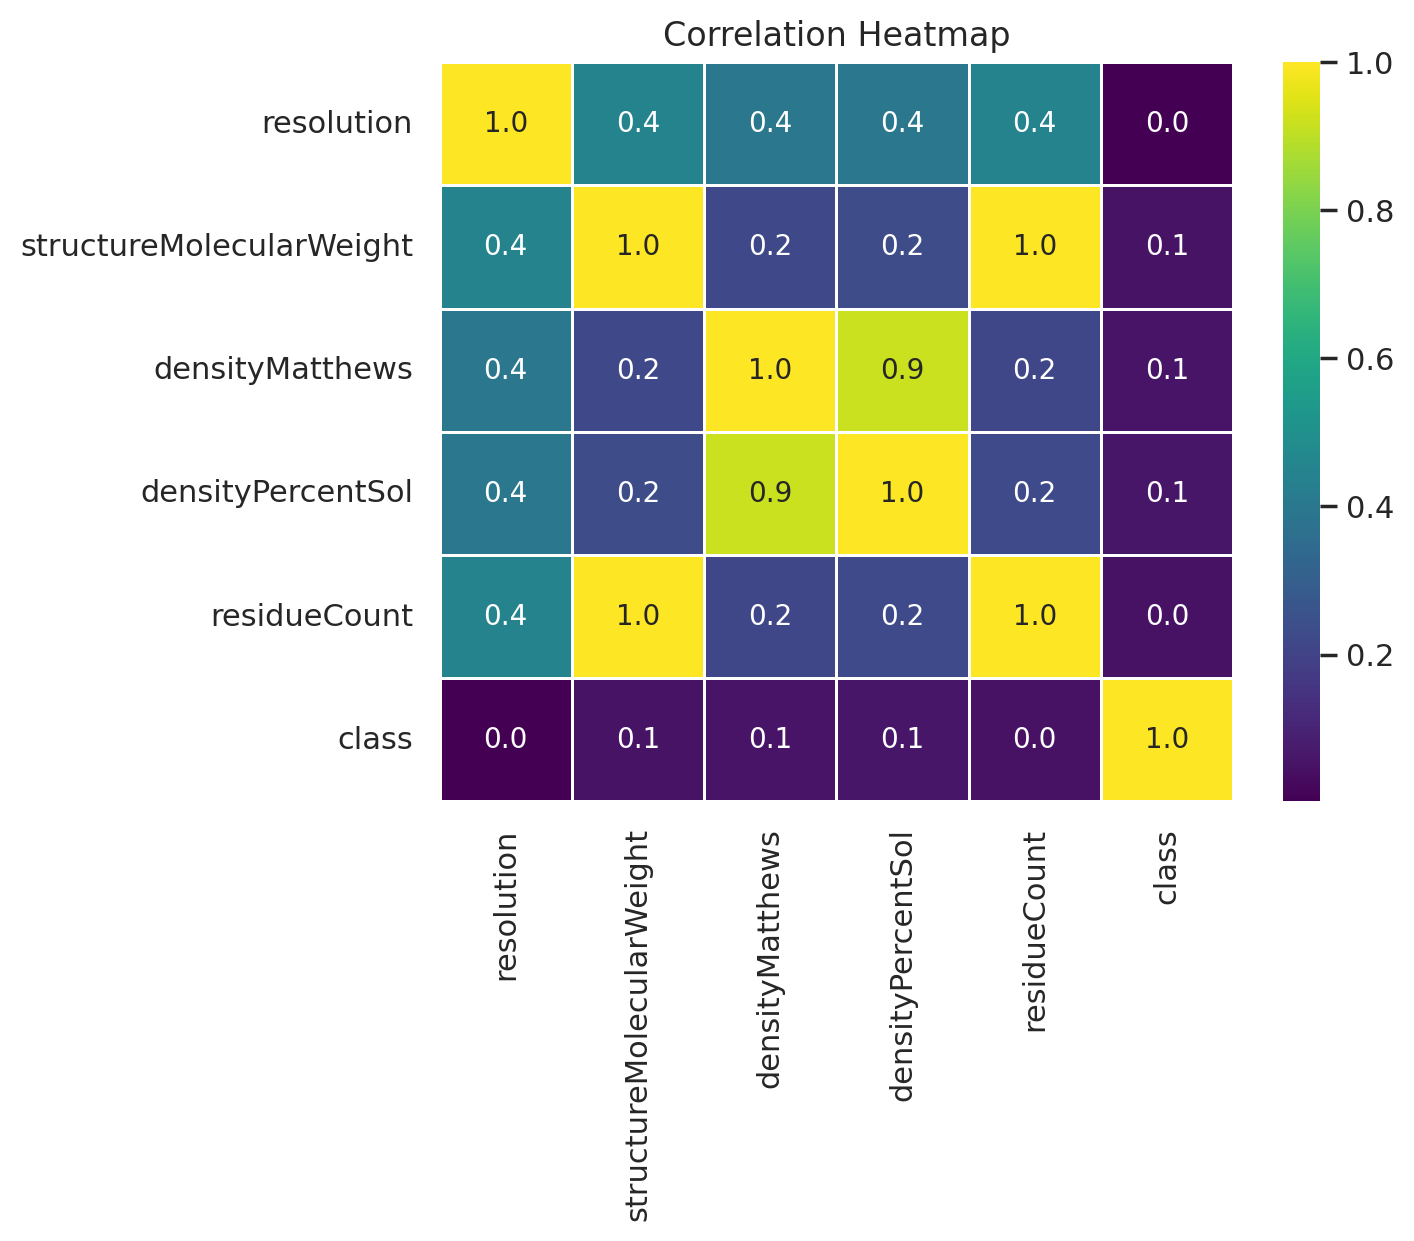

In [ ]:
# %% [code]
plt.figure(dpi=200)
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidth=0.5, cmap='viridis', fmt='.1f', annot_kws={'fontsize':10})
plt.title('Correlation Heatmap')
plt.show()

<Figure size 1600x1600 with 0 Axes>

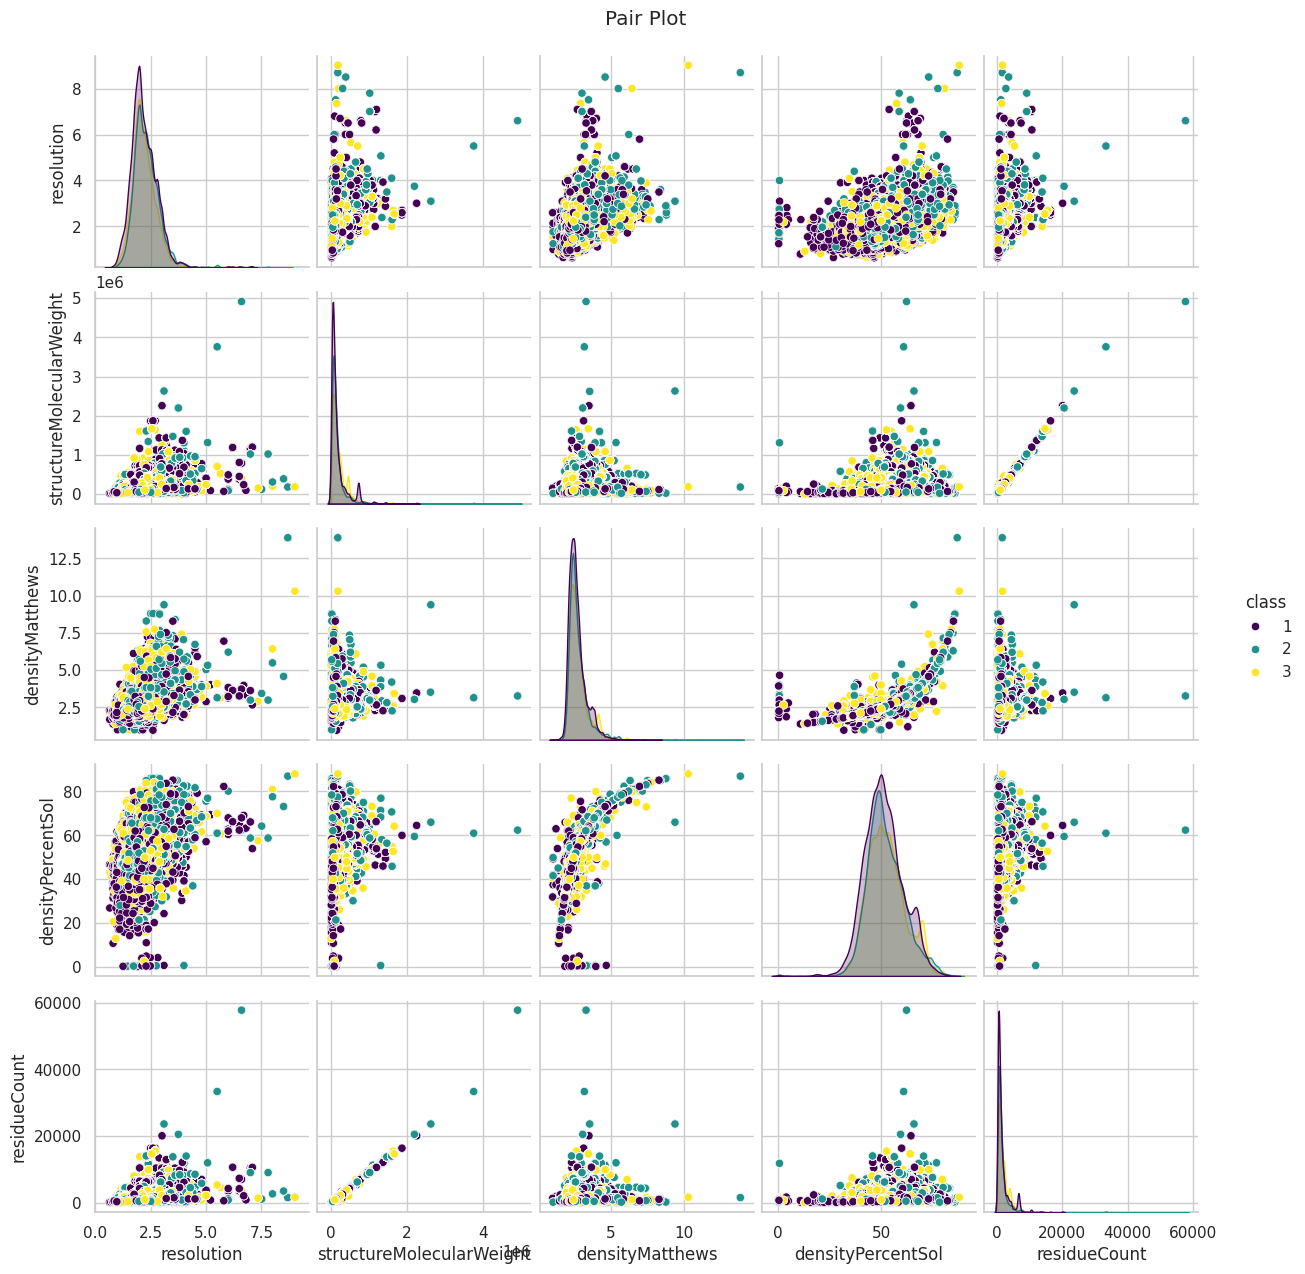

In [ ]:
# Pairplot (only if the number of rows is not too large)

import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(8, 8), dpi=200)
sns.pairplot(df, hue='class', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot', y=1.02)
plt.savefig('Pair Plot', dpi=200)
plt.show()

# Feature Engineering, Train-Test Split, and Standardization

We now separate features and target, split the data into training and testing sets, and standardize the feature values.


In [ ]:
# %% [code]
# Separate features and target variable
X = df.drop('class', axis=1)
y = df['class']

# Perform train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train-test split complete. Training set shape:", X_train.shape)


Train-test split complete. Training set shape: (77932, 5)


# Model Building: K-Nearest Neighbors (KNN) Classifier

Next, we train a KNN classifier (using k = 1, as indicated in the source files) and evaluate its performance.


In [ ]:
# %% [code]
# Initialize and train the KNN classifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# Predict on the test set
knn_preds = knn_model.predict(X_test_scaled)

# Evaluate the model
print("KNN Classification Report:")
print(classification_report(y_test, knn_preds))

KNN Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.76      0.72     13034
           2       0.66      0.66      0.66     10399
           3       0.77      0.66      0.71      9967

    accuracy                           0.70     33400
   macro avg       0.70      0.69      0.70     33400
weighted avg       0.70      0.70      0.70     33400



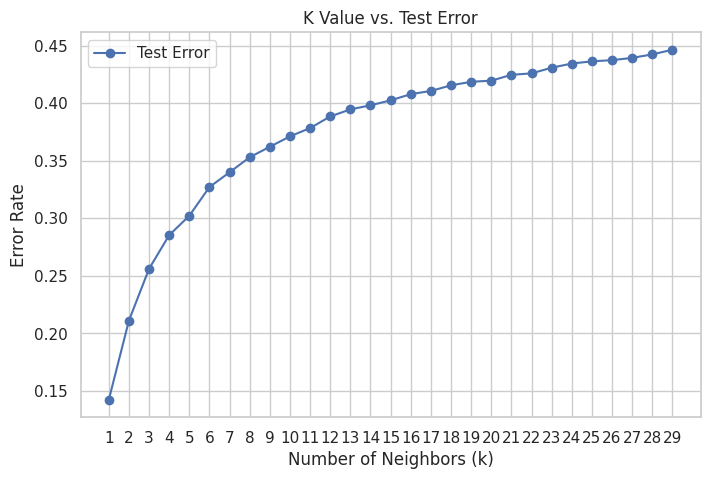

In [ ]:
# %% [code]
# Elbow Method to find the optimal k (Computationally intensive)

error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, pred_k)
    error_rates.append(error)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 30), error_rates, marker='o', label='Test Error')
plt.title('K Value vs. Test Error')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate')
plt.xticks(range(1, 30))
plt.legend()
plt.show()



In [ ]:
# %% [code]

#From the above graph we can conclude that model perform better when n_neighbours = 1

# Initialize and train the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train_scaled, y_train)

# Predict on the test set
knn_preds = knn_model.predict(X_test_scaled)

# Evaluate the model
print("KNN Classification Report:")
print(classification_report(y_test, knn_preds))



KNN Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.86      0.86     13034
           2       0.83      0.84      0.84     10399
           3       0.87      0.87      0.87      9967

    accuracy                           0.86     33400
   macro avg       0.86      0.86      0.86     33400
weighted avg       0.86      0.86      0.86     33400



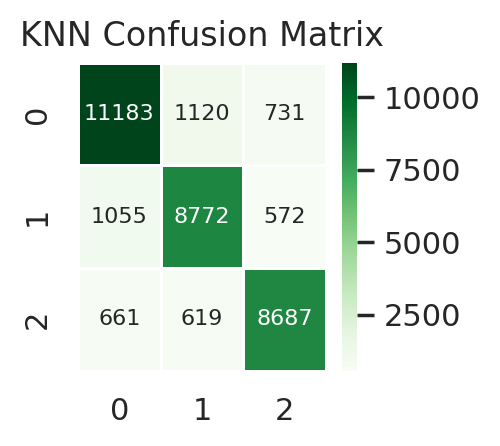

In [ ]:
# Plot the confusion matrix for KNN
knn_cm = confusion_matrix(y_test, knn_preds)
plt.figure(figsize=(2, 2), dpi=200)
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens', linewidth=0.5, annot_kws={"size": 8})
plt.title('KNN Confusion Matrix')
plt.show()

# Model Building: Random Forest Classifier

Train a Random Forest classifier with preset hyperparameters.


In [ ]:
# %% [code]
# Initialize and train the Random Forest classifier

rf_model = RandomForestClassifier(n_estimators=50)

rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
rf_preds = rf_model.predict(X_test_scaled)

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.93      0.91     13034
           2       0.90      0.90      0.90     10399
           3       0.95      0.90      0.93      9967

    accuracy                           0.91     33400
   macro avg       0.91      0.91      0.91     33400
weighted avg       0.91      0.91      0.91     33400



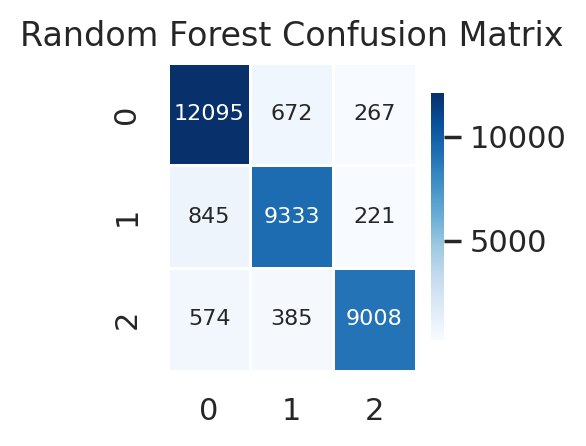

In [ ]:
# Plot the confusion matrix
rf_cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(2, 2), dpi=200)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', linewidth=0.5,
annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})

plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
# %% [code]
# Choosing the right number of estimators in Random Forest Classifier (Computationally Intensive)

# Store test error rates for different numbers of estimators
test_error_RF = []

# Loop through different values of n_estimators
for n in range(1, 51):  # You can increase the range if needed
    rf_model = RandomForestClassifier(n_estimators=n)
    rf_model.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_preds_RF = rf_model.predict(X_test_scaled)

    # Calculate the error rate
    error_RF = 1 - accuracy_score(y_test, y_preds_RF)
    test_error_RF.append(error_RF)

# Convert to Pandas Series for easy indexing and display
test_error_RF_series = pd.Series(np.round(test_error_RF, 4))

# Print the first few test error values
print("Test Error Scores for different n_estimators:")
print(test_error_RF_series.head(5))

Test Error Scores for different n_estimators:
0    0.1768
1    0.1708
2    0.1286
3    0.1272
4    0.1152
dtype: float64


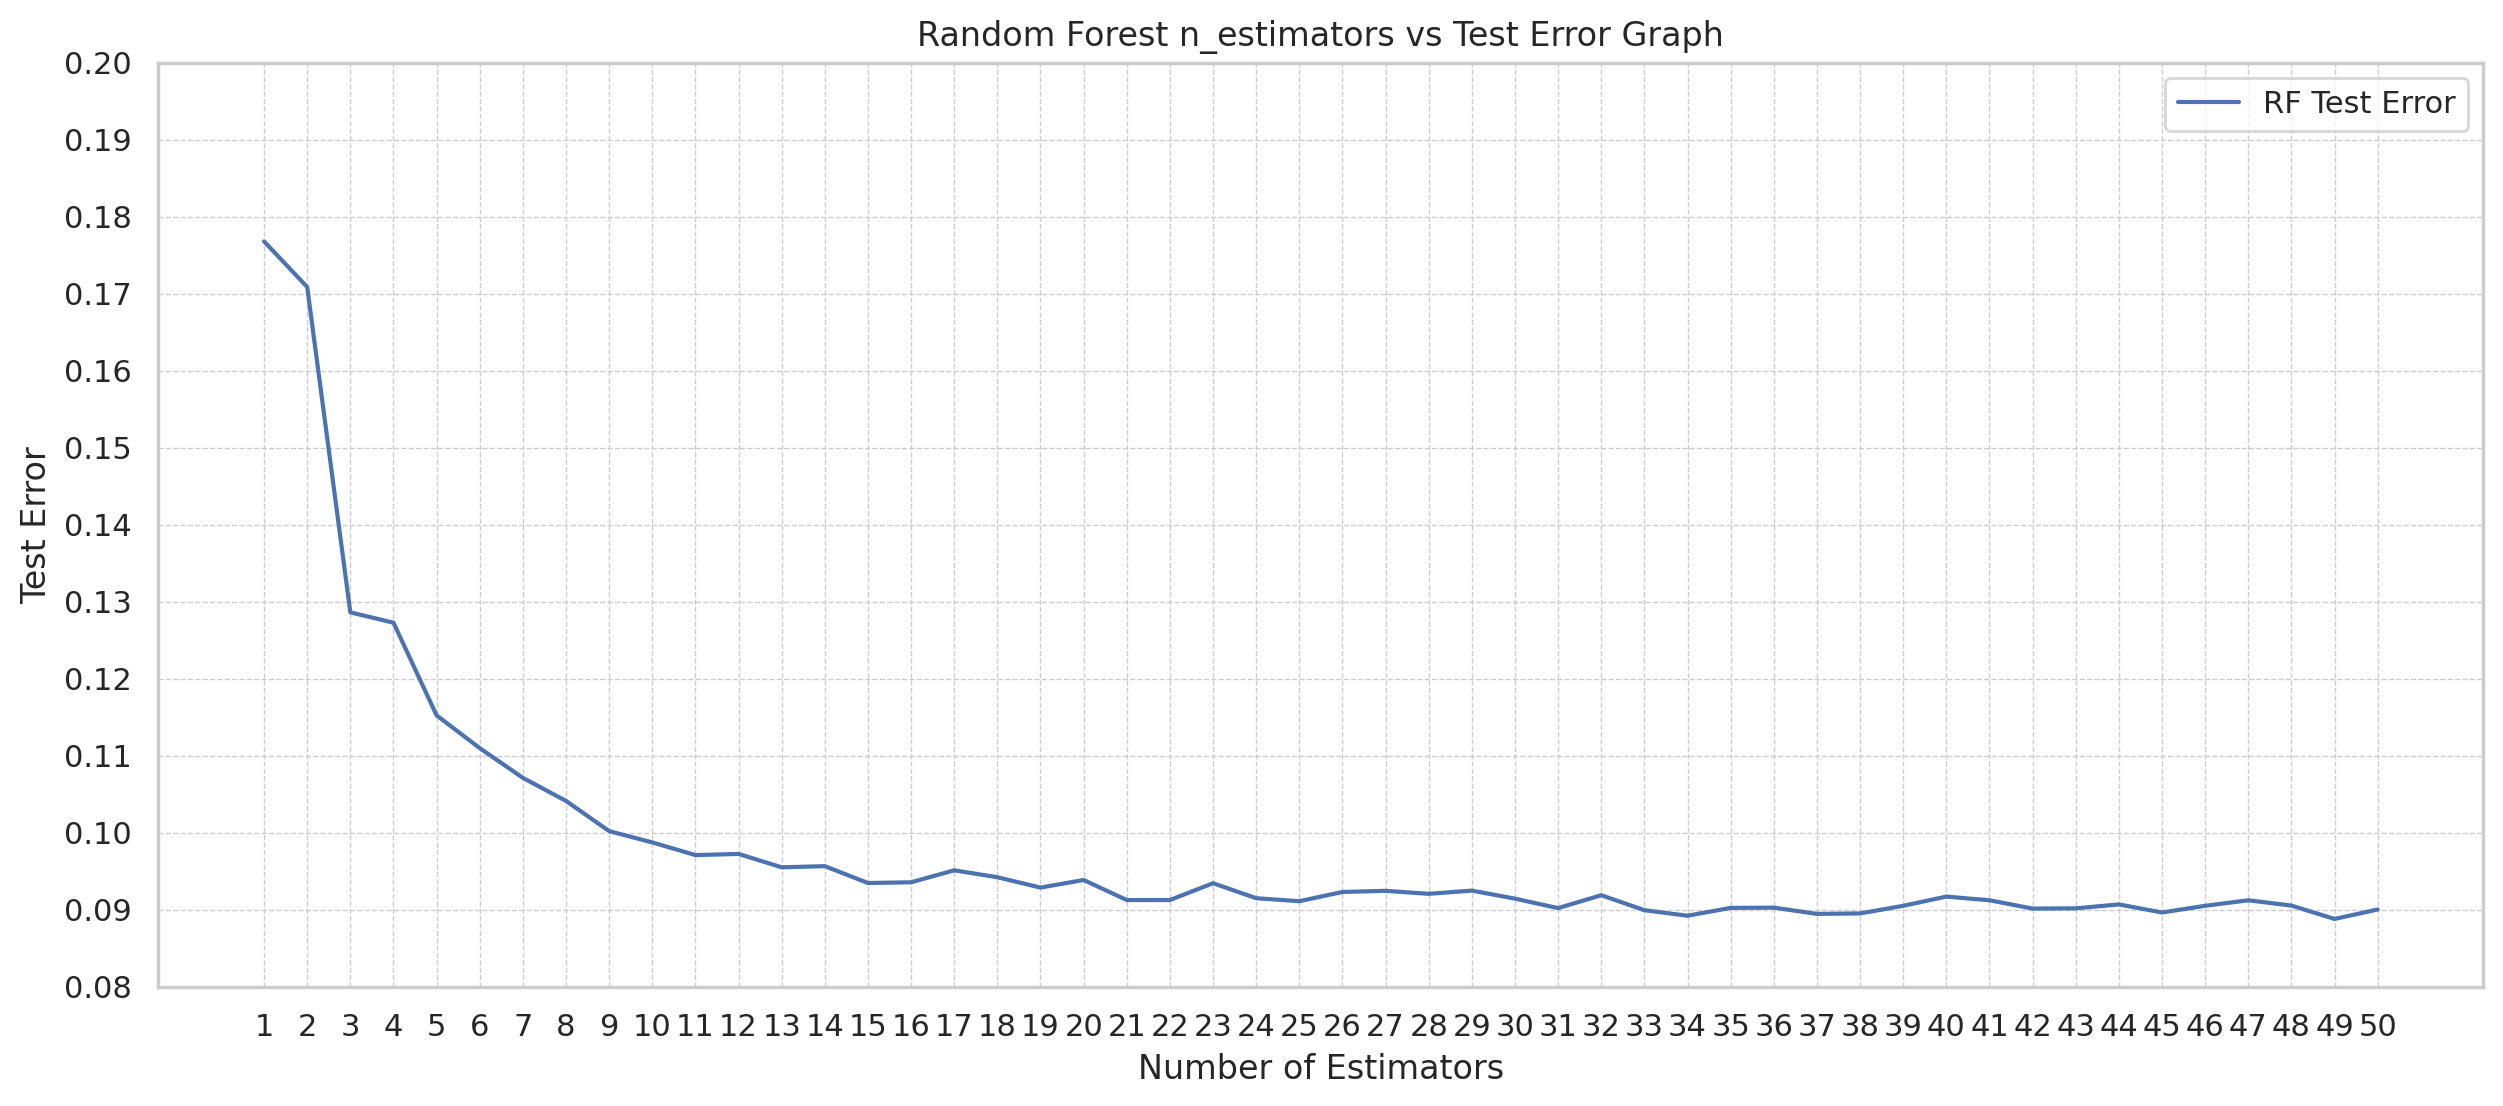

In [ ]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(range(1, 51), test_error_RF, linestyle='-', label='RF Test Error', color='b')
plt.ylabel('Test Error')
plt.xlabel('Number of Estimators')
plt.xticks(range(1, 51, 1))
plt.yticks(np.arange(0.08, 0.21, 0.01))
plt.title('Random Forest n_estimators vs Test Error Graph')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [ ]:
# %% [code]

#From the above graph we can conclude that Random Forest algorithm gives optimal results when n_estimators=21

# Initialize and train the Random Forest classifier

rf_model = RandomForestClassifier(n_estimators=21)

rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
rf_preds = rf_model.predict(X_test_scaled)

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.93      0.91     13034
           2       0.90      0.89      0.90     10399
           3       0.95      0.90      0.92      9967

    accuracy                           0.91     33400
   macro avg       0.91      0.91      0.91     33400
weighted avg       0.91      0.91      0.91     33400



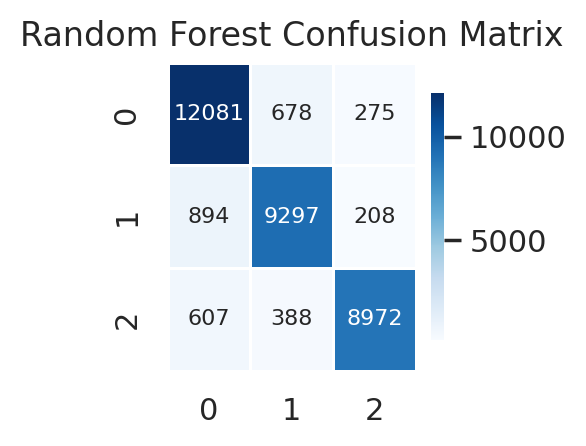

In [ ]:
# Plot the confusion matrix
rf_cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(2, 2), dpi=200)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', linewidth=0.5,
annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})

plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
#Hyperparameter Tuning Code [Computationally Intensive]

# Perform hyperparameter tuning via GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [21, 25, 30, 34],
    'max_features': [2, 3, 4, 5],
    'bootstrap': [True, False]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train_scaled, y_train)
print("Best parameters found:", grid.best_params_)
rf_best = grid.best_estimator_
rf_best_preds = rf_best.predict(X_test_scaled)
print(classification_report(y_test, rf_best_preds))


Best parameters found: {'bootstrap': True, 'max_features': 5, 'n_estimators': 34}
              precision    recall  f1-score   support

           1       0.90      0.93      0.91     13034
           2       0.90      0.90      0.90     10399
           3       0.95      0.91      0.93      9967

    accuracy                           0.91     33400
   macro avg       0.91      0.91      0.91     33400
weighted avg       0.91      0.91      0.91     33400

